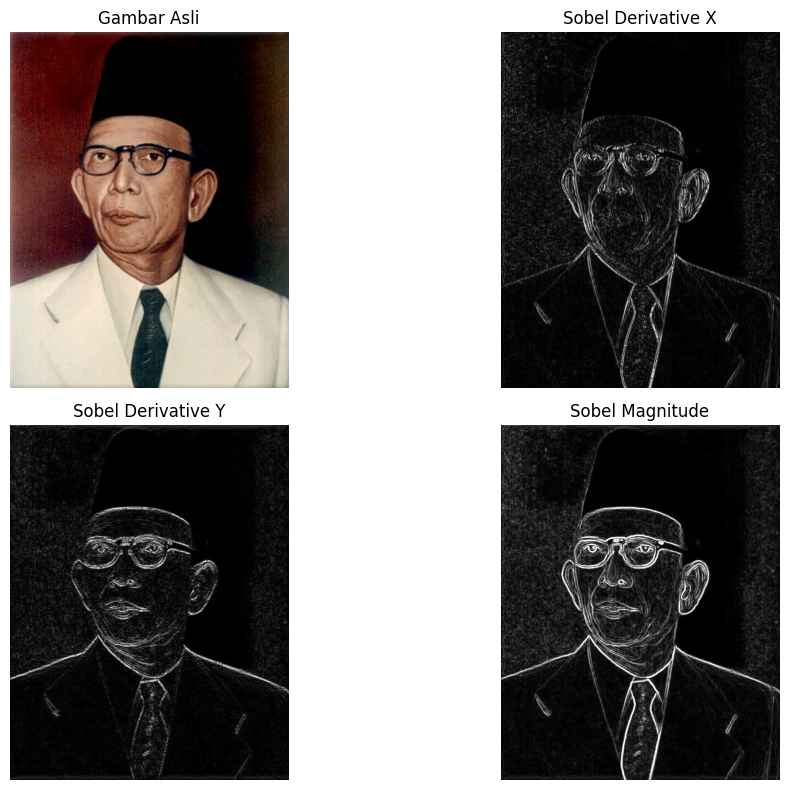

Tekan tombol apapun pada jendela gambar untuk menutup.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def mySobel(img):
    # 1. Konversi ke grayscale jika gambar masih berwarna
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    # Pastikan tipe data float agar perhitungan akurat (mencegah clipping/overflow)
    gray = gray.astype(float)
    
    # 2. Definisi Kernel Sobel (High Pass Filter)
    # Kernel untuk turunan X (mendeteksi garis vertikal)
    kernel_x = np.array([[-1, 0, 1],
                         [-2, 0, 2],
                         [-1, 0, 1]])
    
    # Kernel untuk turunan Y (mendeteksi garis horizontal)
    kernel_y = np.array([[-1, -2, -1],
                         [ 0,  0,  0],
                         [ 1,  2,  1]])

    # 3. Proses Konvolusi Manual menggunakan cv2.filter2D
    # (Hanya menggunakan filter2D untuk konvolusi, logic sobel tetap manual)
    sobel_x = cv2.filter2D(gray, -1, kernel_x)
    sobel_y = cv2.filter2D(gray, -1, kernel_y)

    # 4. Hitung Magnitude (Magnitudo Gradien)
    # Rumus: G = sqrt(Gx^2 + Gy^2)
    magnitude = np.sqrt(np.square(sobel_x) + np.square(sobel_y))
    
    # Normalisasi kembali ke rentang 0-255 (uint8) agar bisa ditampilkan
    sobel_x = np.uint8(np.absolute(sobel_x))
    sobel_y = np.uint8(np.absolute(sobel_y))
    magnitude = np.uint8(np.clip(magnitude, 0, 255))

    return sobel_x, sobel_y, magnitude

# --- Main Program ---

# Load Gambar
path = 'Ki-Hadjar-Dewantara.jpg'
img_original = cv2.imread(path)

if img_original is None:
    print(f"Error: File {path} tidak ditemukan. Pastikan file ada di folder yang sama.")
else:
    # Panggil fungsi buatan sendiri
    derivative_x, derivative_y, magnitude = mySobel(img_original)

    # Konversi BGR ke RGB untuk visualisasi Matplotlib yang benar
    img_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

    # Menampilkan hasil dengan Matplotlib Subplot
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Gambar Asli')
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(derivative_x, cmap='gray')
    plt.title('Sobel Derivative X')
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.imshow(derivative_y, cmap='gray')
    plt.title('Sobel Derivative Y')
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.imshow(magnitude, cmap='gray')
    plt.title('Sobel Magnitude')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Menampilkan juga dengan cv2.imshow (sesuai instruksi)
    cv2.imshow('Original', img_original)
    cv2.imshow('Sobel X', derivative_x)
    cv2.imshow('Sobel Y', derivative_y)
    cv2.imshow('Magnitude', magnitude)
    
    print("Tekan tombol apapun pada jendela gambar untuk menutup.")
    cv2.waitKey(0)
    cv2.destroyAllWindows()